In [2]:
import pandas as pd

print("Python is working!")

Python is working!


In [3]:
import os

os.listdir("../data/raw")

['superstore.csv']

In [4]:
df = pd.read_csv("../data/raw/superstore.csv")

df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,...,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,...,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,...,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


In [5]:
df.shape

(51290, 27)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  str    
 1   City            51290 non-null  str    
 2   Country         51290 non-null  str    
 3   Customer.ID     51290 non-null  str    
 4   Customer.Name   51290 non-null  str    
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  str    
 7   记录数             51290 non-null  int64  
 8   Order.Date      51290 non-null  str    
 9   Order.ID        51290 non-null  str    
 10  Order.Priority  51290 non-null  str    
 11  Product.ID      51290 non-null  str    
 12  Product.Name    51290 non-null  str    
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  str    
 16  Row.ID          51290 non-null  int64  
 17  Sales           51290 non-null  int64  
 1

In [7]:
df.isnull().sum()

Category          0
City              0
Country           0
Customer.ID       0
Customer.Name     0
Discount          0
Market            0
记录数               0
Order.Date        0
Order.ID          0
Order.Priority    0
Product.ID        0
Product.Name      0
Profit            0
Quantity          0
Region            0
Row.ID            0
Sales             0
Segment           0
Ship.Date         0
Ship.Mode         0
Shipping.Cost     0
State             0
Sub.Category      0
Year              0
Market2           0
weeknum           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.nunique()

Category              3
City               3636
Country             147
Customer.ID        4873
Customer.Name       795
Discount             27
Market                7
记录数                   1
Order.Date         1430
Order.ID          25035
Order.Priority        4
Product.ID        10292
Product.Name       3788
Profit            24575
Quantity             14
Region               13
Row.ID            51290
Sales              2246
Segment               3
Ship.Date          1464
Ship.Mode             4
Shipping.Cost     16877
State              1094
Sub.Category         17
Year                  4
Market2               6
weeknum              53
dtype: int64

In [10]:
print("Category:")
print(df["Category"].unique())

print("\nSegment:")
print(df["Segment"].unique())

print("\nMarket:")
print(df["Market"].unique())

print("\nShip Mode:")
print(df["Ship.Mode"].unique())

Category:
<StringArray>
['Office Supplies', 'Technology', 'Furniture']
Length: 3, dtype: str

Segment:
<StringArray>
['Consumer', 'Home Office', 'Corporate']
Length: 3, dtype: str

Market:
<StringArray>
['US', 'EU', 'LATAM', 'Africa', 'APAC', 'EMEA', 'Canada']
Length: 7, dtype: str

Ship Mode:
<StringArray>
['Second Class', 'Standard Class', 'Same Day', 'First Class']
Length: 4, dtype: str


In [11]:
df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

Category
Technology         4744691
Furniture          4110884
Office Supplies    3787330
Name: Sales, dtype: int64

In [12]:
df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

Category
Technology         663778.73318
Office Supplies    518473.83430
Furniture          285204.72380
Name: Profit, dtype: float64

In [13]:
category_analysis = df.groupby("Category")[["Sales", "Profit"]].sum()

category_analysis

,Sales,Profit
Category,,
Furniture,4110884,285204.72380
Office Supplies,3787330,518473.83430
Technology,4744691,663778.73318


In [14]:
category_analysis["Profit Margin (%)"] = (
    category_analysis["Profit"] / category_analysis["Sales"]
) * 100

category_analysis

,Sales,Profit,Profit Margin (%)
Category,,,
Furniture,4110884,285204.72380,6.937795
Office Supplies,3787330,518473.83430,13.689693
Technology,4744691,663778.73318,13.989925


In [15]:
df.groupby("Sub.Category")["Sales"].sum().sort_values(ascending=False)

Sub.Category
Phones         1706874
Copiers        1509439
Chairs         1501682
Bookcases      1466559
Storage        1127124
Appliances     1011081
Machines        779071
Tables          757034
Accessories     749307
Binders         461952
Furnishings     385609
Art             372163
Paper           244307
Supplies        243090
Envelopes       170926
Fasteners        83254
Labels           73433
Name: Sales, dtype: int64

In [16]:
df.groupby("Sub.Category")["Profit"].sum().sort_values(ascending=False)

Sub.Category
Copiers        258567.54818
Phones         216717.00580
Bookcases      161924.41950
Appliances     141680.58940
Chairs         140396.26750
Accessories    129626.30620
Storage        108461.48980
Binders         72449.84600
Paper           59207.68270
Machines        58867.87300
Art             57953.91090
Furnishings     46967.42550
Envelopes       29601.11630
Supplies        22583.26310
Labels          15010.51200
Fasteners       11525.42410
Tables         -64083.38870
Name: Profit, dtype: float64

In [17]:
subcategory_analysis = df.groupby("Sub.Category")[["Sales", "Profit"]].sum()

subcategory_analysis.sort_values("Profit", ascending=False)

,Sales,Profit
Sub.Category,,
Copiers,1509439,258567.54818
Phones,1706874,216717.00580
Bookcases,1466559,161924.41950
Appliances,1011081,141680.58940
Chairs,1501682,140396.26750
Accessories,749307,129626.30620
Storage,1127124,108461.48980
Binders,461952,72449.84600
Paper,244307,59207.68270


In [18]:
df[df["Sub.Category"] == "Tables"][["Sales", "Profit", "Discount"]].describe()

,Sales,Profit,Discount
count,861.000000,861.000000,861.000000
mean,879.249710,-74.429023,0.290732
std,796.399276,402.973963,0.220513
min,24.000000,-2750.280000,0.000000
25%,331.000000,-205.608000,0.200000
50%,629.000000,-34.647000,0.300000
75%,1114.000000,103.040000,0.450000
max,5451.000000,2071.440000,0.850000


In [19]:
df[df["Sub.Category"] == "Tables"].groupby("Discount")["Profit"].mean().sort_index()

Discount
0.00     290.611537
0.10     265.009000
0.20      39.429158
0.30    -103.107574
0.35    -202.725533
0.40    -201.237421
0.45    -276.638662
0.47    -314.125738
0.50    -289.420429
0.55    -315.067200
0.57    -526.129000
0.60    -378.315429
0.70    -591.099845
0.80    -634.741833
0.85   -1534.329000
Name: Profit, dtype: float64

In [20]:
df[df["Sub.Category"] == "Tables"].groupby("Region")["Profit"].sum().sort_values()

Region
South            -27012.3219
Central          -21550.1069
Southeast Asia   -18618.3051
East             -11025.3801
North Asia        -5470.5780
Oceania            -229.7190
Caribbean            63.3880
Canada              300.1800
West               1482.6073
EMEA               2764.2510
Africa             4010.6850
Central Asia       4189.8540
North              7012.0570
Name: Profit, dtype: float64

In [21]:
df[df["Sub.Category"] == "Tables"].groupby("Region")[["Discount", "Profit"]].mean().sort_values("Profit")

,Discount,Profit
Region,,
Southeast Asia,0.480000,-315.564493
South,0.364015,-204.638802
East,0.373750,-137.817251
North Asia,0.326190,-130.251857
Central,0.325602,-129.819921
Oceania,0.273585,-4.334321
Caribbean,0.285185,2.347704
West,0.200000,12.781097
EMEA,0.164444,61.427800


In [22]:
df[df["Sub.Category"] == "Tables"].groupby("Product.Name")["Profit"].sum().sort_values()

Product.Name
Bevis Round Table, Adjustable Height                       -3649.8940
Bevis Computer Table, Fully Assembled                      -3509.5638
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases   -2876.1156
Bevis Wood Table, with Bottom Storage                      -2782.5880
Lesro Training Table, Rectangular                          -2581.2834
                                                              ...    
Hon Training Table, Fully Assembled                         1341.8515
Barricks Conference Table, Fully Assembled                  1574.6550
Barricks Training Table, Adjustable Height                  1758.9735
Hon Training Table, Adjustable Height                       1911.7890
Chromcraft Computer Table, Adjustable Height                3009.1070
Name: Profit, Length: 170, dtype: float64

In [23]:
tables_products = df[df["Sub.Category"] == "Tables"].groupby("Product.Name").agg({
    "Sales": "sum",
    "Profit": "sum",
    "Discount": "mean"
}).sort_values("Profit")

In [24]:
tables_products.head(10)

,Sales,Profit,Discount
Product.Name,,,
"Bevis Round Table, Adjustable Height",5655,-3649.8940,0.460000
"Bevis Computer Table, Fully Assembled",11176,-3509.5638,0.353077
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9918,-2876.1156,0.280000
"Bevis Wood Table, with Bottom Storage",11134,-2782.5880,0.320000
"Lesro Training Table, Rectangular",2712,-2581.2834,0.582000
"Barricks Conference Table, Rectangular",3664,-2487.9675,0.350000
"Bevis Conference Table, Fully Assembled",14885,-2443.0893,0.302500
"Lesro Round Table, Adjustable Height",3961,-2402.9760,0.434000
"Lesro Computer Table, Fully Assembled",7224,-2322.8380,0.400000


In [25]:
df["Order.Date"] = pd.to_datetime(df["Order.Date"])

In [26]:
df["Order.Date"].dtype

dtype('<M8[us]')

In [27]:
year_analysis = df.groupby("Year")[["Sales", "Profit"]].sum()

In [28]:
year_analysis

,Sales,Profit
Year,,
2011,2259511,248940.81154
2012,2677493,307415.27910
2013,3405860,406935.23018
2014,4300041,504165.97046


In [29]:
market_analysis = df.groupby("Market")[["Sales", "Profit"]].sum().sort_values("Profit", ascending=False)

In [30]:
market_analysis

,Sales,Profit
Market,,
APAC,3585833,436000.04900
EU,2938139,372829.74150
US,2297354,286397.02170
LATAM,2164687,221643.48708
Africa,783776,88871.63100
EMEA,806184,43897.97100
Canada,66932,17817.39000


In [31]:
segment_analysis = df.groupby("Segment")[["Sales", "Profit"]].sum().sort_values("Profit", ascending=False)

segment_analysis

,Sales,Profit
Segment,,
Consumer,6508141,749239.78206
Corporate,3824808,441208.32866
Home Office,2309956,277009.18056


In [32]:
#data Cleaning

In [33]:
df.columns

Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name',
       'Discount', 'Market', '记录数', 'Order.Date', 'Order.ID', 'Order.Priority',
       'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Row.ID',
       'Sales', 'Segment', 'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State',
       'Sub.Category', 'Year', 'Market2', 'weeknum'],
      dtype='str')

In [34]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(".", "_", regex=False)
)

df.columns

Index(['category', 'city', 'country', 'customer_id', 'customer_name',
       'discount', 'market', '记录数', 'order_date', 'order_id', 'order_priority',
       'product_id', 'product_name', 'profit', 'quantity', 'region', 'row_id',
       'sales', 'segment', 'ship_date', 'ship_mode', 'shipping_cost', 'state',
       'sub_category', 'year', 'market2', 'weeknum'],
      dtype='str')

In [35]:
df["记录数"].value_counts()

记录数
1    51290
Name: count, dtype: int64

In [36]:
df = df.drop(columns=["记录数"])

In [37]:
df.columns

Index(['category', 'city', 'country', 'customer_id', 'customer_name',
       'discount', 'market', 'order_date', 'order_id', 'order_priority',
       'product_id', 'product_name', 'profit', 'quantity', 'region', 'row_id',
       'sales', 'segment', 'ship_date', 'ship_mode', 'shipping_cost', 'state',
       'sub_category', 'year', 'market2', 'weeknum'],
      dtype='str')

In [38]:
df.isnull().sum()

category          0
city              0
country           0
customer_id       0
customer_name     0
discount          0
market            0
order_date        0
order_id          0
order_priority    0
product_id        0
product_name      0
profit            0
quantity          0
region            0
row_id            0
sales             0
segment           0
ship_date         0
ship_mode         0
shipping_cost     0
state             0
sub_category      0
year              0
market2           0
weeknum           0
dtype: int64

In [39]:
df.duplicated().sum()

np.int64(0)

In [40]:
df.dtypes

category                     str
city                         str
country                      str
customer_id                  str
customer_name                str
discount                 float64
market                       str
order_date        datetime64[us]
order_id                     str
order_priority               str
product_id                   str
product_name                 str
profit                   float64
quantity                   int64
region                       str
row_id                     int64
sales                      int64
segment                      str
ship_date                    str
ship_mode                    str
shipping_cost            float64
state                        str
sub_category                 str
year                       int64
market2                      str
weeknum                    int64
dtype: object

In [42]:
df["ship_date"] = pd.to_datetime(df["ship_date"])

In [43]:
df[["order_date", "ship_date"]].dtypes

order_date    datetime64[us]
ship_date     datetime64[us]
dtype: object

In [44]:
df[["discount", "quantity", "sales", "profit", "shipping_cost"]].describe()

,discount,quantity,sales,profit,shipping_cost
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,0.142908,3.476545,246.498440,28.610982,26.375818
std,0.212280,2.278766,487.567175,174.340972,57.296810
min,0.000000,1.000000,0.000000,-6599.978000,0.002000
25%,0.000000,2.000000,31.000000,0.000000,2.610000
50%,0.000000,3.000000,85.000000,9.240000,7.790000
75%,0.200000,5.000000,251.000000,36.810000,24.450000
max,0.850000,14.000000,22638.000000,8399.976000,933.570000


In [45]:
text_columns = df.select_dtypes(include="str").columns

for col in text_columns:
    print(col, df[col].str.strip().ne(df[col]).sum())

category 0
city 0
country 0
customer_id 0
customer_name 0
market 0
order_id 0
order_priority 0
product_id 0
product_name 0
region 0
segment 0
ship_mode 0
state 0
sub_category 0
market2 0


In [46]:
(df["ship_date"] < df["order_date"]).sum()

np.int64(0)

In [47]:
(df["sales"] == 0).sum()

np.int64(1)

In [48]:
(df["quantity"] <= 0).sum()

np.int64(0)

In [49]:
df[df["sales"] == 0]

,category,city,country,customer_id,customer_name,discount,market,order_date,order_id,order_priority,...,sales,segment,ship_date,ship_mode,shipping_cost,state,sub_category,year,market2,weeknum
46158,Office Supplies,Houston,United States,ZC-219104,Zuschuss Carroll,0.8,US,2014-06-20,US-2014-102288,Medium,...,0,Consumer,2014-06-24,Standard Class,0.01,Texas,Appliances,2014,North America,25


In [50]:
df.loc[df["sales"] == 0, ["sales", "profit", "quantity", "discount", "shipping_cost"]]

,sales,profit,quantity,discount,shipping_cost
46158,0,-1.11,1,0.8,0.01


In [51]:
df["row_id"].nunique()
len(df)

51290

In [52]:
for col in ["category", "segment", "ship_mode", "market", "order_priority"]:
    print("\n", col)
    print(df[col].unique())


 category
<StringArray>
['Office Supplies', 'Technology', 'Furniture']
Length: 3, dtype: str

 segment
<StringArray>
['Consumer', 'Home Office', 'Corporate']
Length: 3, dtype: str

 ship_mode
<StringArray>
['Second Class', 'Standard Class', 'Same Day', 'First Class']
Length: 4, dtype: str

 market
<StringArray>
['US', 'EU', 'LATAM', 'Africa', 'APAC', 'EMEA', 'Canada']
Length: 7, dtype: str

 order_priority
<StringArray>
['High', 'Medium', 'Critical', 'Low']
Length: 4, dtype: str


In [53]:
df.shape

(51290, 26)

In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   category        51290 non-null  str           
 1   city            51290 non-null  str           
 2   country         51290 non-null  str           
 3   customer_id     51290 non-null  str           
 4   customer_name   51290 non-null  str           
 5   discount        51290 non-null  float64       
 6   market          51290 non-null  str           
 7   order_date      51290 non-null  datetime64[us]
 8   order_id        51290 non-null  str           
 9   order_priority  51290 non-null  str           
 10  product_id      51290 non-null  str           
 11  product_name    51290 non-null  str           
 12  profit          51290 non-null  float64       
 13  quantity        51290 non-null  int64         
 14  region          51290 non-null  str           
 15  row_id       

In [55]:
df.to_csv("../data/clean/superstore_clean.csv", index=False)

In [56]:
import os

os.path.exists("../data/clean/superstore_clean.csv")

True

In [63]:
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


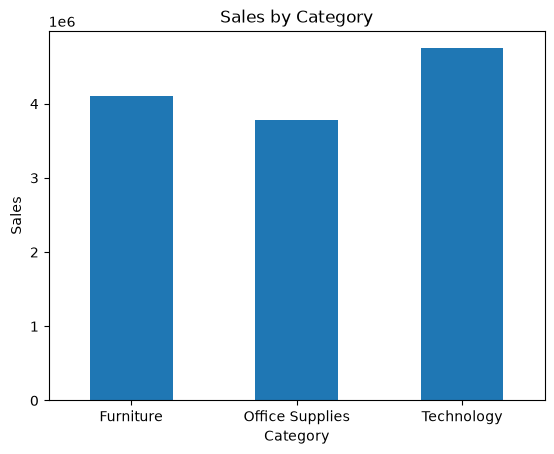

In [64]:
import matplotlib.pyplot as plt

category_sales = df.groupby("category")["sales"].sum()

category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

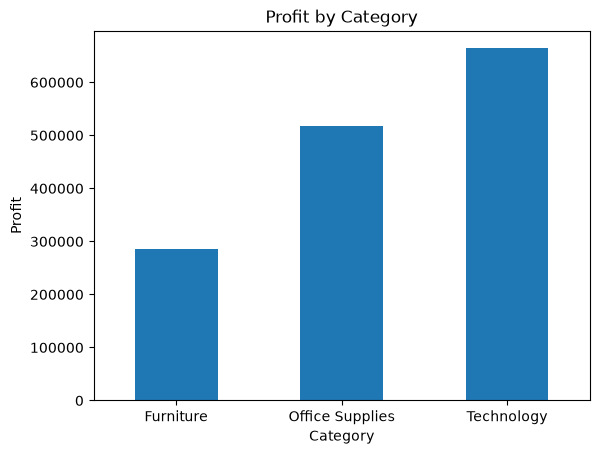

In [65]:
category_profit = df.groupby("category")["profit"].sum()

category_profit.plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=0)
plt.show()

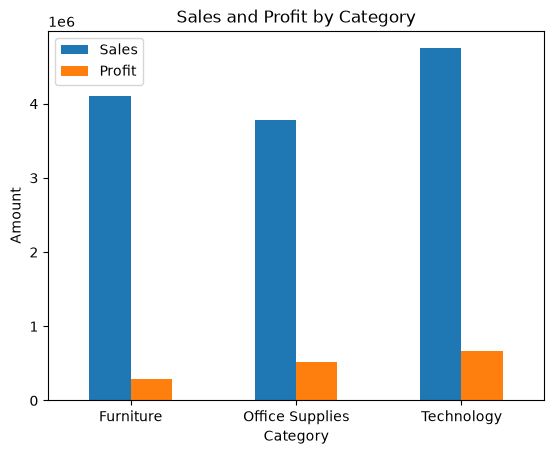

In [66]:
category_analysis = df.groupby("category")[["sales", "profit"]].sum()

category_analysis.plot(kind="bar")

plt.title("Sales and Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.legend(["Sales", "Profit"])
plt.show()

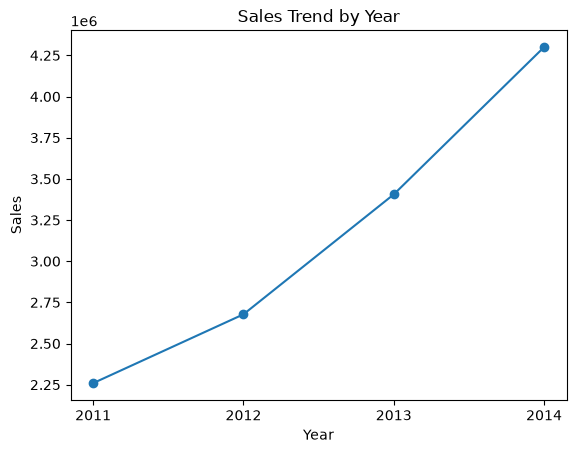

In [67]:
year_sales = df.groupby("year")["sales"].sum()

year_sales.plot(kind="line", marker="o")

plt.title("Sales Trend by Year")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.xticks(year_sales.index)
plt.show()

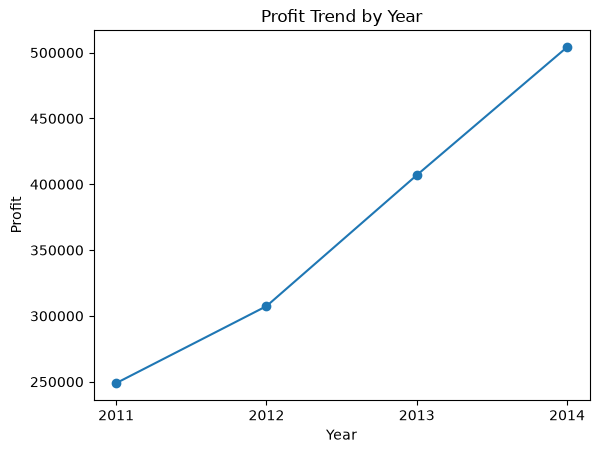

In [68]:
year_profit = df.groupby("year")["profit"].sum()

year_profit.plot(kind="line", marker="o")

plt.title("Profit Trend by Year")
plt.xlabel("Year")
plt.ylabel("Profit")
plt.xticks(year_profit.index)
plt.show()

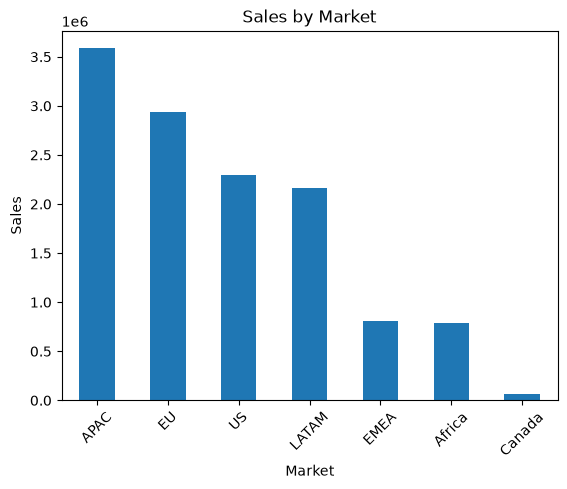

In [69]:
market_sales = df.groupby("market")["sales"].sum().sort_values(ascending=False)

market_sales.plot(kind="bar")

plt.title("Sales by Market")
plt.xlabel("Market")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

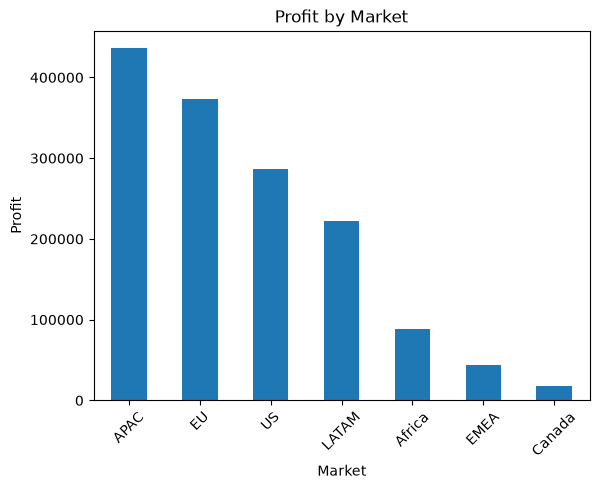

In [70]:
market_profit = df.groupby("market")["profit"].sum().sort_values(ascending=False)

market_profit.plot(kind="bar")

plt.title("Profit by Market")
plt.xlabel("Market")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

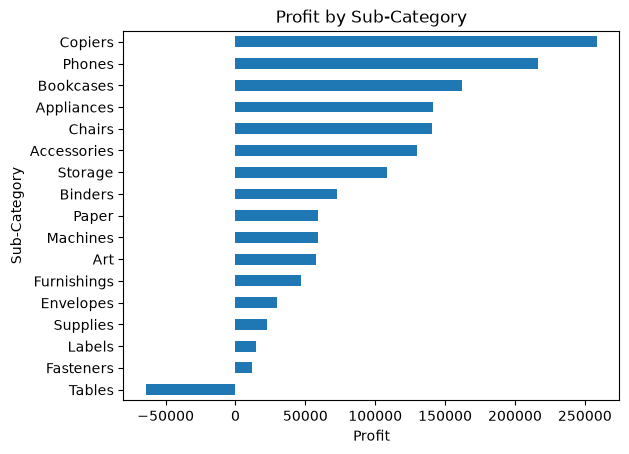

In [71]:
subcategory_profit = df.groupby("sub_category")["profit"].sum().sort_values()

subcategory_profit.plot(kind="barh")

plt.title("Profit by Sub-Category")
plt.xlabel("Profit")
plt.ylabel("Sub-Category")
plt.show()

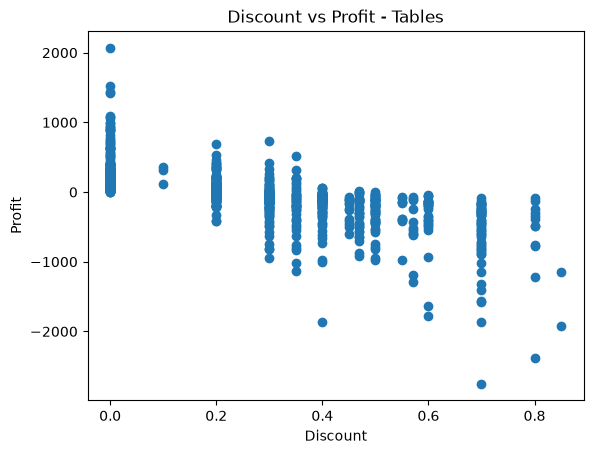

In [72]:
tables = df[df["sub_category"] == "Tables"]

plt.scatter(tables["discount"], tables["profit"])

plt.title("Discount vs Profit - Tables")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

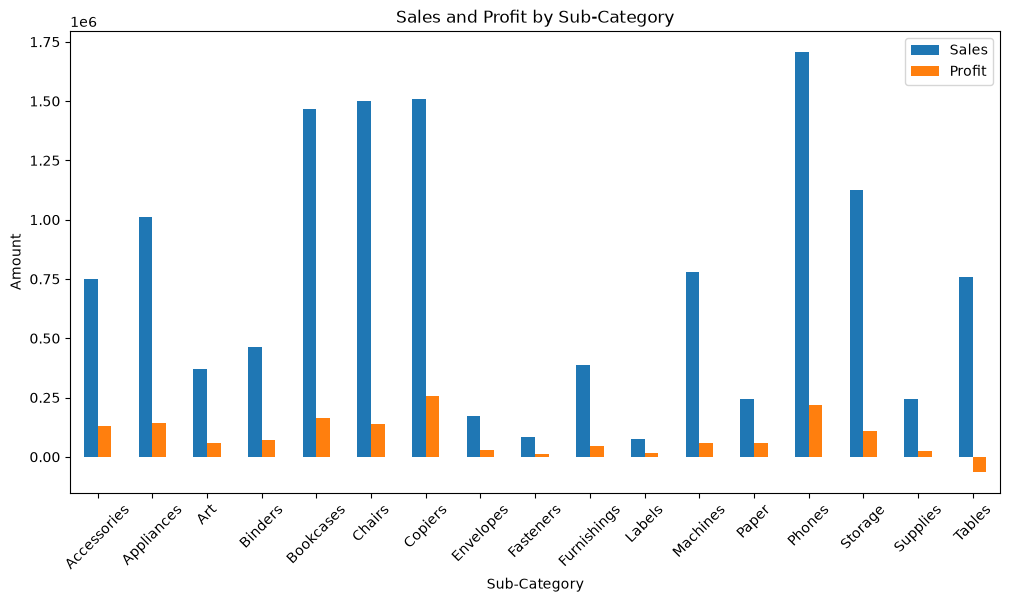

In [73]:
subcategory_analysis = df.groupby("sub_category")[["sales", "profit"]].sum()

subcategory_analysis.plot(kind="bar", figsize=(12,6))

plt.title("Sales and Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.legend(["Sales", "Profit"])
plt.show()

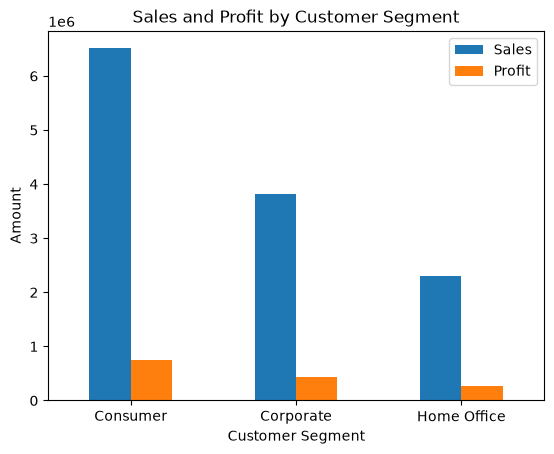

In [74]:
segment_analysis = df.groupby("segment")[["sales", "profit"]].sum()

segment_analysis.plot(kind="bar")

plt.title("Sales and Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.legend(["Sales", "Profit"])
plt.show()